In [1]:
import pmdarima as pm

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
from IPython.display import display
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

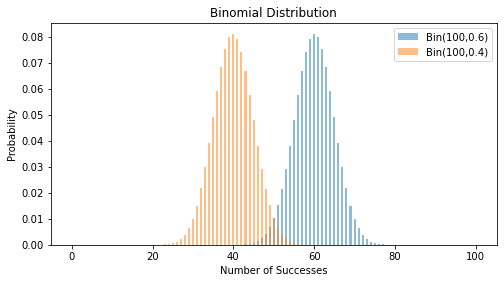

In [3]:
from scipy.stats import binom, poisson, norm, expon, uniform

N_BINS= 100

# draw a Binomial distribution
n = 100
p = 0.6
x = np.linspace(0, n, N_BINS, dtype=int)

_, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
ax.bar(x, binom.pmf(x, n, p), width=0.5, label=f"Bin({n},{p:.1f})", alpha=0.5)
ax.bar(x, binom.pmf(x, n, 1-p), width=0.5, label=f"Bin({n},{1-p:.1f})", alpha=0.5)
ax.set(xlabel='Number of Successes', ylabel='Probability', title='Binomial Distribution')
plt.legend()
plt.show()

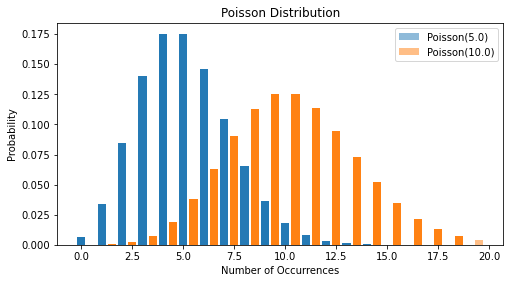

In [4]:
# draw a Poisson distribution
mu = 5
x = np.linspace(poisson.ppf(1e-6, mu), poisson.ppf(1-1e-6, mu), N_BINS, dtype=int)

_, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
ax.bar(x, poisson.pmf(x, mu), width=0.4, label=f"Poisson({mu:.1f})", alpha=0.5)
ax.bar(x+0.5, poisson.pmf(x, 2*mu), width=0.4, label=f"Poisson({2*mu:.1f})", alpha=0.5)
ax.set(xlabel='Number of Occurrences', ylabel='Probability', title='Poisson Distribution')
plt.legend()
plt.show()

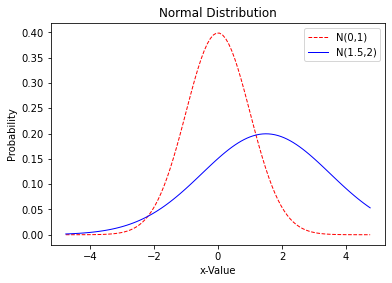

In [5]:
# draw a normal distribution
x = np.linspace(norm.ppf(1e-6), norm.ppf(1-1e-6), N_BINS)

_, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(x, norm.pdf(x), 'r--', lw=1, label="N(0,1)")
ax.plot(x, norm.pdf(x, loc=1.5, scale=2), 'b', lw=1, label="N(1.5,2)")
ax.set(xlabel='x-Value', ylabel='Probability', title='Normal Distribution')
plt.legend()
plt.show()

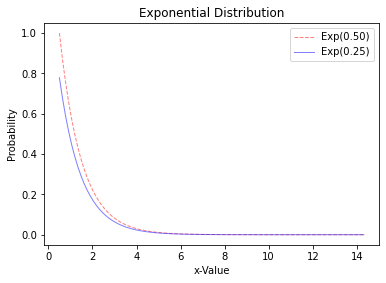

In [6]:
# draw an exponential distribution
rate = 0.5
x = np.linspace(expon.ppf(1e-6, rate), expon.ppf(1-1e-6, rate), N_BINS)

_, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(x, expon.pdf(x, rate), 'r--', lw=1, label=f"Exp({rate:.2f})", alpha=0.5)
ax.plot(x, expon.pdf(x, 0.5*rate), 'b', lw=1, label=f"Exp({0.5*rate:.2f})", alpha=0.5)
ax.set(xlabel='x-Value', ylabel='Probability', title='Exponential Distribution')
plt.legend()
plt.show()

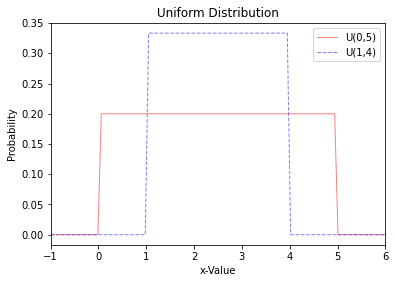

In [7]:
# draw a uniform distribution
a, b = 0, 5
x = np.linspace(a-1, b+1, N_BINS)

_, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(x, uniform.pdf(x, loc=a, scale=b-a), 'r', lw=1, label=f"U({a},{b})", alpha=0.5)
ax.plot(x, uniform.pdf(x, loc=a+1, scale=b-1-(a+1)), 'b--', lw=1, label=f"U({a+1},{b-1})", alpha=0.5)
ax.set(xlim=(a-1,b+1), xlabel='x-Value', ylabel='Probability', title='Uniform Distribution')
plt.legend()
plt.show()

In [8]:
# get the dataset
df = pd.read_csv('../../datasets/PJME_hourly.csv', parse_dates=[0])  # parse dates
df = df.sort_values(by='Datetime')
df = df.reset_index(drop=True)

# sanity
display(df.head())
print(f'#rows= {len(df)}')

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


#rows= 145366


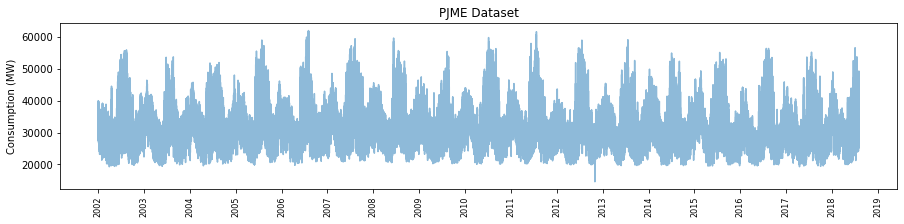

In [9]:
_, ax = plt.subplots(1, figsize=(15, 3))

ax.plot(df['Datetime'], df['PJME_MW'], alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set(ylabel='Consumption (MW)', title='PJME Dataset')
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.show()

In [10]:
# arbitrary dates
DATE_SPLIT_BEG= '01-Jan-2016'
DATE_SPLIT_END= '31-Jan-2016'
DATE_SPLIT_TESTEND= '1-Feb-2016'

df_train = df.loc[(DATE_SPLIT_BEG<=df.Datetime) & (df.Datetime<DATE_SPLIT_END)].copy()
df_train.reset_index(drop=True, inplace=True)
df_test = df.loc[(DATE_SPLIT_END<=df.Datetime) & (df.Datetime<DATE_SPLIT_TESTEND)].copy()
df_test.reset_index(drop=True, inplace=True)

# sanity
print(len(df_train), len(df_test))

720 24


In [11]:
# timeseries data
time = pd.date_range(df_train['Datetime'][0], periods=len(df_train), freq='h')
tsdata = pd.Series(df_train['PJME_MW'].values, index=time)
tsdata.head()

2016-01-01 00:00:00    26686.0
2016-01-01 01:00:00    25509.0
2016-01-01 02:00:00    24599.0
2016-01-01 03:00:00    23896.0
2016-01-01 04:00:00    23567.0
Freq: h, dtype: float64

In [12]:
%%time

# Automatically find the best ARIMA model parameters
model = pm.auto_arima(tsdata, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# Print the best model parameters
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11613.190, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12343.758, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11861.808, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11846.677, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=12341.774, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=11708.305, Time=0.17 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=11647.959, Time=0.14 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=11609.486, Time=0.44 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=11692.705, Time=0.10 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=11460.362, Time=0.59 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=11580.449, Time=0.17 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=11441.904, Time=0.78 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=11577.214, Time=0.22 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=11434.779, Time=0.69 sec
 ARIMA(4,1,3)(0,0,0

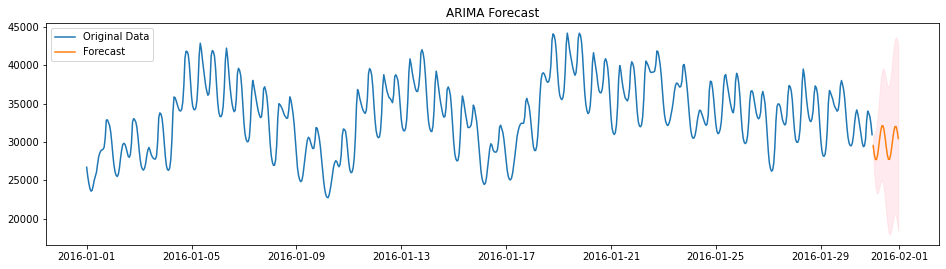

In [13]:
# Forecast the next periods
n_periods = 24
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# Create a date range for the forecast
forecast_index = pd.date_range(tsdata.index[-1], periods=n_periods+1, freq='h')[1:]

# Plot the original data and the forecast
_, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 4))
ax.plot(tsdata, label='Original Data')
plt.plot(forecast_index, forecast, label='Forecast')
plt.fill_between(forecast_index, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(df_test['PJME_MW'].values, forecast)
print(f'MSE= {mse:,.0f}')

mape = mean_absolute_percentage_error(df_test['PJME_MW'].values, forecast)
print(f'MAPE= {mape:.5f}')

MSE= 2,398,667
MAPE= 0.04439
